In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

In [ ]:
os.makedirs('output', exist_ok=True)
print("Output folder ready.")

Output folder ready.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data analytics/Week 03/age_networth.csv')

print("Shape:", df.shape)
print()
print(df.to_string(index=False))

Shape: (10, 2)

 Age  Net Worth
  20      20000
  30     150000
  40     250000
  45     300000
  50     200000
  55     250000
  60     500000
  65     800000
  75    1200000
  85     900000


In [ ]:
df.head()

,Age,Net Worth
0,20,20000
1,30,150000
2,40,250000
3,45,300000
4,50,200000


In [ ]:
df.describe().round(2)

,Age,Net Worth
count,10.00,10.00
mean,52.50,457000.00
std,19.90,384333.48
min,20.00,20000.00
25%,41.25,212500.00
50%,52.50,275000.00
75%,63.75,725000.00
max,85.00,1200000.00


using pandas

In [ ]:
r_pandas = df['Age'].corr(df['Net Worth'])
print(f"Pearson r (pandas): {r_pandas:.4f}")

Pearson r (pandas): 0.8824


using scipy

In [ ]:
r_scipy, p_value = stats.pearsonr(df['Age'], df['Net Worth'])

print(f"Pearson r  : {r_scipy:.4f}")
print(f"p-value    : {p_value:.4f}")
print(f"Significant: {p_value < 0.05}  (threshold = 0.05)")

Pearson r  : 0.8824
p-value    : 0.0007
Significant: True  (threshold = 0.05)


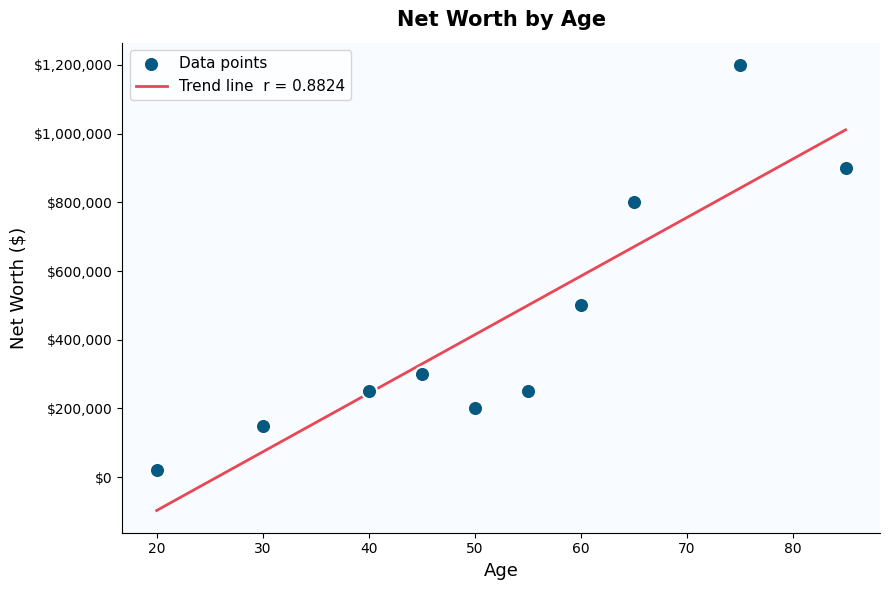

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter points
ax.scatter(df['Age'], df['Net Worth'],
           color='#065A82', s=120, zorder=5,
           edgecolors='white', linewidth=1.5,
           label='Data points')

# Regression trend line
m, b = np.polyfit(df['Age'], df['Net Worth'], 1)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 200)
ax.plot(x_line, m * x_line + b,
        color='#E84855', linewidth=2,
        label=f'Trend line  r = {r_scipy:.4f}')

# Formatting
ax.set_title('Net Worth by Age', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Net Worth ($)', fontsize=13)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#F8FBFF')

plt.tight_layout()
plt.savefig('output/scatter_age_networth.png', dpi=150)
plt.show()

Strength   : strong positive correlation

  Interpretation:

  r = 0.8824 shows a strong positive linear relationship between Age and Net Worth

  As age increases, net worth tends to increase

